In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import ttest_ind
import seaborn as sns
import warnings as ws
ws.filterwarnings('ignore')

In [2]:
# ---------------- Load Data ----------------
dataset = pd.read_csv("Pancreatic_Cancer.csv")

In [3]:
# ---------------- Data Cleaning ----------------
print("Duplicates:", dataset.duplicated().sum())
dataset = dataset.drop_duplicates()   # actually remove them if any exist

Duplicates: 0


In [4]:
dataset

,Patient_ID,Demographic_1,Demographic_2,Demographic_3,Demographic_4,Demographic_5,Demographic_6,Demographic_7,Demographic_8,Demographic_9,...,Genetic_7,Genetic_8,Genetic_9,Genetic_10,Risk_1,Risk_2,Risk_3,Risk_4,Risk_5,Cancer_Stage
0,PC000001,12.95,6.03,26.04,2.90,21.44,14.63,2.32,20.30,1.50,...,15.96,4.14,25.37,2.49,2.69,8.35,6.49,13.60,2.10,Healthy
1,PC000002,0.01,6.05,4.06,14.54,1.02,34.97,24.56,5.94,10.09,...,21.27,20.94,0.75,17.60,7.32,0.16,31.97,6.89,18.94,Healthy
2,PC000003,29.01,22.26,13.04,20.73,22.22,31.37,4.24,22.41,9.94,...,18.99,37.39,4.25,32.76,17.29,19.80,33.38,15.72,20.27,Healthy
3,PC000004,27.51,39.30,13.71,33.29,28.27,25.44,16.19,13.90,2.18,...,18.59,18.65,4.74,35.75,7.97,39.13,37.45,0.70,18.36,Healthy
4,PC000005,32.80,38.72,17.98,10.75,8.39,37.82,8.43,23.26,5.67,...,28.38,35.83,18.93,23.49,0.01,15.66,37.07,33.02,34.22,Healthy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,PC059996,96.41,125.47,8.79,45.86,80.52,25.35,73.54,40.22,45.90,...,47.56,80.76,17.38,124.89,60.15,38.87,113.66,11.36,64.49,Stage IV
59996,PC059997,112.86,79.98,26.03,42.83,120.30,34.89,121.25,52.08,118.62,...,75.81,69.73,32.63,93.49,32.83,28.21,75.68,83.28,84.55,Stage IV
59997,PC059998,92.03,116.48,42.54,26.40,87.23,66.82,32.16,43.93,76.39,...,22.66,48.25,104.37,17.66,39.18,77.80,49.11,72.92,21.91,Stage IV
59998,PC059999,14.27,38.09,23.87,122.81,35.86,39.87,46.73,52.67,43.35,...,87.79,4.54,89.95,35.54,63.08,109.71,118.98,115.20,101.42,Stage IV


In [5]:
print("Missing values:\n", dataset.isnull().sum())

Missing values:
 Patient_ID       0
Demographic_1    0
Demographic_2    0
Demographic_3    0
Demographic_4    0
                ..
Risk_2           0
Risk_3           0
Risk_4           0
Risk_5           0
Cancer_Stage     0
Length: 132, dtype: int64


In [6]:
# ---------------- Drop ID column ----------------
dataset = dataset.drop(columns=['Patient_ID'])

In [7]:
dataset

,Demographic_1,Demographic_2,Demographic_3,Demographic_4,Demographic_5,Demographic_6,Demographic_7,Demographic_8,Demographic_9,Demographic_10,...,Genetic_7,Genetic_8,Genetic_9,Genetic_10,Risk_1,Risk_2,Risk_3,Risk_4,Risk_5,Cancer_Stage
0,12.95,6.03,26.04,2.90,21.44,14.63,2.32,20.30,1.50,17.35,...,15.96,4.14,25.37,2.49,2.69,8.35,6.49,13.60,2.10,Healthy
1,0.01,6.05,4.06,14.54,1.02,34.97,24.56,5.94,10.09,13.90,...,21.27,20.94,0.75,17.60,7.32,0.16,31.97,6.89,18.94,Healthy
2,29.01,22.26,13.04,20.73,22.22,31.37,4.24,22.41,9.94,11.08,...,18.99,37.39,4.25,32.76,17.29,19.80,33.38,15.72,20.27,Healthy
3,27.51,39.30,13.71,33.29,28.27,25.44,16.19,13.90,2.18,5.19,...,18.59,18.65,4.74,35.75,7.97,39.13,37.45,0.70,18.36,Healthy
4,32.80,38.72,17.98,10.75,8.39,37.82,8.43,23.26,5.67,20.96,...,28.38,35.83,18.93,23.49,0.01,15.66,37.07,33.02,34.22,Healthy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,96.41,125.47,8.79,45.86,80.52,25.35,73.54,40.22,45.90,68.74,...,47.56,80.76,17.38,124.89,60.15,38.87,113.66,11.36,64.49,Stage IV
59996,112.86,79.98,26.03,42.83,120.30,34.89,121.25,52.08,118.62,119.04,...,75.81,69.73,32.63,93.49,32.83,28.21,75.68,83.28,84.55,Stage IV
59997,92.03,116.48,42.54,26.40,87.23,66.82,32.16,43.93,76.39,116.90,...,22.66,48.25,104.37,17.66,39.18,77.80,49.11,72.92,21.91,Stage IV
59998,14.27,38.09,23.87,122.81,35.86,39.87,46.73,52.67,43.35,45.30,...,87.79,4.54,89.95,35.54,63.08,109.71,118.98,115.20,101.42,Stage IV


In [8]:
# ---------------- Identify categorical columns (before encoding) ----------------
quali_cols = dataset.select_dtypes(include='object').columns.tolist()
quan_cols = dataset.select_dtypes(exclude='object').columns.tolist()
print("Categorical columns:", quali_cols)

Categorical columns: ['Cancer_Stage']


In [9]:
quan_cols

['Demographic_1',
 'Demographic_2',
 'Demographic_3',
 'Demographic_4',
 'Demographic_5',
 'Demographic_6',
 'Demographic_7',
 'Demographic_8',
 'Demographic_9',
 'Demographic_10',
 'Lifestyle_1',
 'Lifestyle_2',
 'Lifestyle_3',
 'Lifestyle_4',
 'Lifestyle_5',
 'Lifestyle_6',
 'Lifestyle_7',
 'Lifestyle_8',
 'Lifestyle_9',
 'Lifestyle_10',
 'Lifestyle_11',
 'Lifestyle_12',
 'History_1',
 'History_2',
 'History_3',
 'History_4',
 'History_5',
 'History_6',
 'History_7',
 'History_8',
 'History_9',
 'History_10',
 'History_11',
 'History_12',
 'History_13',
 'History_14',
 'History_15',
 'History_16',
 'History_17',
 'History_18',
 'Symptom_1',
 'Symptom_2',
 'Symptom_3',
 'Symptom_4',
 'Symptom_5',
 'Symptom_6',
 'Symptom_7',
 'Symptom_8',
 'Symptom_9',
 'Symptom_10',
 'Symptom_11',
 'Symptom_12',
 'Symptom_13',
 'Symptom_14',
 'Symptom_15',
 'Symptom_16',
 'Symptom_17',
 'Symptom_18',
 'Symptom_19',
 'Symptom_20',
 'Vital_1',
 'Vital_2',
 'Vital_3',
 'Vital_4',
 'Vital_5',
 'Vital_6',


In [10]:
# ---------------- Encode Target (Ordinal - has natural order) ----------------
# One-Hot Encoding for categorical data - Newyork, Texas, New jersey
# Label Encoding-  Binary categories like yes/No, True/False
# Ordinal Encoding - low, high, medium
# Here predict different stages of disease present or not. use Ordinal Encoding
stageOrder = [['Healthy', 'High Risk', 'Stage I', 'Stage II', 'Stage III', 'Stage IV']]
encoder = OrdinalEncoder(categories=stageOrder)
dataset['Cancer_Stage'] = encoder.fit_transform(dataset[['Cancer_Stage']])


In [11]:
dataset['Cancer_Stage']

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
59995    5.0
59996    5.0
59997    5.0
59998    5.0
59999    5.0
Name: Cancer_Stage, Length: 60000, dtype: float64

In [12]:
# Remove target from the list of columns still needing encoding
quali_cols.remove('Cancer_Stage')

In [13]:
# ---------------- Encode remaining categorical features (One-Hot encoding) ----------------
if quali_cols:
    dataset = pd.get_dummies(dataset, columns=quali_cols, drop_first=True, dtype=int)

In [14]:
dataset

,Demographic_1,Demographic_2,Demographic_3,Demographic_4,Demographic_5,Demographic_6,Demographic_7,Demographic_8,Demographic_9,Demographic_10,...,Genetic_7,Genetic_8,Genetic_9,Genetic_10,Risk_1,Risk_2,Risk_3,Risk_4,Risk_5,Cancer_Stage
0,12.95,6.03,26.04,2.90,21.44,14.63,2.32,20.30,1.50,17.35,...,15.96,4.14,25.37,2.49,2.69,8.35,6.49,13.60,2.10,0.0
1,0.01,6.05,4.06,14.54,1.02,34.97,24.56,5.94,10.09,13.90,...,21.27,20.94,0.75,17.60,7.32,0.16,31.97,6.89,18.94,0.0
2,29.01,22.26,13.04,20.73,22.22,31.37,4.24,22.41,9.94,11.08,...,18.99,37.39,4.25,32.76,17.29,19.80,33.38,15.72,20.27,0.0
3,27.51,39.30,13.71,33.29,28.27,25.44,16.19,13.90,2.18,5.19,...,18.59,18.65,4.74,35.75,7.97,39.13,37.45,0.70,18.36,0.0
4,32.80,38.72,17.98,10.75,8.39,37.82,8.43,23.26,5.67,20.96,...,28.38,35.83,18.93,23.49,0.01,15.66,37.07,33.02,34.22,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,96.41,125.47,8.79,45.86,80.52,25.35,73.54,40.22,45.90,68.74,...,47.56,80.76,17.38,124.89,60.15,38.87,113.66,11.36,64.49,5.0
59996,112.86,79.98,26.03,42.83,120.30,34.89,121.25,52.08,118.62,119.04,...,75.81,69.73,32.63,93.49,32.83,28.21,75.68,83.28,84.55,5.0
59997,92.03,116.48,42.54,26.40,87.23,66.82,32.16,43.93,76.39,116.90,...,22.66,48.25,104.37,17.66,39.18,77.80,49.11,72.92,21.91,5.0
59998,14.27,38.09,23.87,122.81,35.86,39.87,46.73,52.67,43.35,45.30,...,87.79,4.54,89.95,35.54,63.08,109.71,118.98,115.20,101.42,5.0


In [15]:
# ---------------- Calculate Central Dependency ----------------
descriptive = pd.DataFrame(index=["Mean", "Median", "Mode", "Q1:25%", "Q2:50%", "Q3:75%","Max", "IQR", "1.5Rule","Lesser","Greater","Min","Max","Skew","Kurtosis",'Var', 'StdVar',"Values","Frequency", "Relative Frequency", "Cusum Frequency"], columns=quan_cols)
for colName in quan_cols:            
     descriptive[colName]["Mean"]= dataset[colName].mean()
     descriptive[colName]["Median"]=  dataset[colName].median()
     descriptive[colName]["Mode"]=  dataset[colName].mode()[0]
     descriptive[colName]["Q1:25%"]=  dataset.describe()[colName]["25%"]
     descriptive[colName]["Q2:50%"]= dataset.describe()[colName]["50%"]
     descriptive[colName]["Q3:75%"]= dataset.describe()[colName]["75%"]             
     descriptive[colName]["Max"]=  dataset.describe()[colName]["max"]
     descriptive[colName]["IQR"]=  descriptive[colName]["Q3:75%"] - descriptive[colName]["Q1:25%"]
     descriptive[colName]["1.5Rule"] = 1.5 * descriptive[colName]["IQR"]
     descriptive[colName]["Lesser"] =descriptive[colName]["Q1:25%"]-descriptive[colName]["1.5Rule"]
     descriptive[colName]["Greater"] = descriptive[colName]["Q3:75%"]+ descriptive[colName]["1.5Rule"]
     descriptive[colName]["Min"]=dataset[colName].min()
     descriptive[colName]["Max"]=dataset[colName].max()
     descriptive[colName]["Skew"]=dataset[colName].skew()
     descriptive[colName]["Kurtosis"]=dataset[colName].kurtosis()
     descriptive[colName]["Var"]=dataset[colName].var()
     descriptive[colName]["StdVar"]=dataset[colName].std()
     descriptive[colName]["Values"] = dataset[colName].value_counts().index
     descriptive[colName]["Frequency"] = dataset[colName].value_counts().values
     tableLength = len( descriptive[colName]["Values"])
     descriptive[colName]["Relative Frequency"]= descriptive[colName]["Frequency"]/tableLength
     descriptive [colName]["Cusum Frequency"]= descriptive[colName]["Relative Frequency"].cumsum()


In [16]:
descriptive

,Demographic_1,Demographic_2,Demographic_3,Demographic_4,Demographic_5,Demographic_6,Demographic_7,Demographic_8,Demographic_9,Demographic_10,...,Genetic_6,Genetic_7,Genetic_8,Genetic_9,Genetic_10,Risk_1,Risk_2,Risk_3,Risk_4,Risk_5
Mean,33.48007,33.325305,33.544614,33.354803,33.612495,33.372469,33.473955,33.388951,33.434477,33.316493,...,33.418804,33.436857,33.413787,33.558028,33.602592,33.450419,33.472064,33.462531,33.353473,33.381526
Median,28.51,28.31,28.5,28.25,28.66,28.42,28.52,28.34,28.49,28.35,...,28.425,28.55,28.4,28.58,28.49,28.38,28.52,28.39,28.36,28.39
Mode,19.35,23.26,17.34,34.36,21.67,27.66,2.43,39.4,32.13,35.64,...,7.96,14.21,9.99,31.51,24.68,5.21,26.99,10.74,28.3,27.69
Q1:25%,14.1675,14.13,14.33,14.19,14.16,14.3275,14.1475,14.27,14.19,14.13,...,14.15,14.28,14.3175,14.38,14.33,14.2375,14.32,14.29,14.07,14.24
Q2:50%,28.51,28.31,28.5,28.25,28.66,28.42,28.52,28.34,28.49,28.35,...,28.425,28.55,28.4,28.58,28.49,28.38,28.52,28.39,28.36,28.39
Q3:75%,46.34,46.13,46.4025,46.0325,46.68,46.07,46.28,45.87,46.16,45.99,...,46.23,46.14,46.34,46.19,46.81,46.31,46.41,46.17,46.35,46.18
Max,126.85,126.92,126.97,126.99,126.96,126.96,127.0,126.99,126.9,127.0,...,126.96,126.94,126.97,126.97,126.96,126.94,126.95,126.96,127.0,126.89
IQR,32.1725,32.0,32.0725,31.8425,32.52,31.7425,32.1325,31.6,31.97,31.86,...,32.08,31.86,32.0225,31.81,32.48,32.0725,32.09,31.88,32.28,31.94
1.5Rule,48.25875,48.0,48.10875,47.76375,48.78,47.61375,48.19875,47.4,47.955,47.79,...,48.12,47.79,48.03375,47.715,48.72,48.10875,48.135,47.82,48.42,47.91
Lesser,-34.09125,-33.87,-33.77875,-33.57375,-34.62,-33.28625,-34.05125,-33.13,-33.765,-33.66,...,-33.97,-33.51,-33.71625,-33.335,-34.39,-33.87125,-33.815,-33.53,-34.35,-33.67


In [18]:
# ---------------- Check Covariance----------------
dataset.iloc[:, :].cov(numeric_only=True)

,Demographic_1,Demographic_2,Demographic_3,Demographic_4,Demographic_5,Demographic_6,Demographic_7,Demographic_8,Demographic_9,Demographic_10,...,Genetic_7,Genetic_8,Genetic_9,Genetic_10,Risk_1,Risk_2,Risk_3,Risk_4,Risk_5,Cancer_Stage
Demographic_1,634.203781,189.189276,199.154153,189.775490,197.223394,194.560398,197.651506,197.233685,196.832716,191.498532,...,193.981981,191.930822,196.635378,197.112388,194.990629,194.281750,200.982962,196.934399,194.879965,20.855586
Demographic_2,189.189276,626.606396,192.503485,194.015408,192.603623,192.648013,191.164210,191.547041,190.666283,190.264523,...,194.764408,189.819933,197.223241,194.686416,197.749504,191.979943,197.768271,191.491428,186.761250,20.571518
Demographic_3,199.154153,192.503485,635.644589,197.525401,200.751086,188.866504,193.509836,195.457819,195.205745,197.485381,...,194.601311,195.799426,194.067332,196.761903,191.581653,193.135731,197.059592,192.926826,193.807226,20.934859
Demographic_4,189.775490,194.015408,197.525401,633.875566,195.470212,195.041233,195.287707,199.605352,191.160392,187.965543,...,193.247170,191.195295,194.501679,196.437119,194.849159,193.967634,197.811596,196.163942,189.490824,20.764330
Demographic_5,197.223394,192.603623,200.751086,195.470212,638.656873,190.981305,195.452061,194.823247,197.163321,194.908164,...,194.140367,197.733468,195.890441,199.413692,194.644634,192.447325,200.667431,196.383354,195.055295,20.953603
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Risk_2,194.281750,191.979943,193.135731,193.967634,192.447325,196.443959,191.342058,188.393359,191.005753,193.862384,...,188.398569,194.495785,192.787024,199.497845,190.114924,629.597701,198.859454,193.547499,192.450038,20.617789
Risk_3,200.982962,197.768271,197.059592,197.811596,200.667431,191.755395,193.053277,189.669120,198.502428,193.626912,...,200.186388,195.566997,201.234689,192.580940,194.716188,198.859454,639.087648,198.506696,194.231557,21.046200
Risk_4,196.934399,191.491428,192.926826,196.163942,196.383354,188.666405,192.761906,192.609142,194.045073,189.104019,...,193.888686,189.506482,193.104146,198.812206,191.887186,193.547499,198.506696,630.042693,191.808661,20.641862
Risk_5,194.879965,186.761250,193.807226,189.490824,195.055295,192.164187,193.887651,190.447704,190.739373,195.735020,...,192.582684,188.892011,194.272521,195.415644,190.566086,192.450038,194.231557,191.808661,628.282850,20.490767


In [19]:
# ---------------- Check Correlation----------------
dataset.iloc[:, :].corr(numeric_only=True)

,Demographic_1,Demographic_2,Demographic_3,Demographic_4,Demographic_5,Demographic_6,Demographic_7,Demographic_8,Demographic_9,Demographic_10,...,Genetic_7,Genetic_8,Genetic_9,Genetic_10,Risk_1,Risk_2,Risk_3,Risk_4,Risk_5,Cancer_Stage
Demographic_1,1.000000,0.300113,0.313666,0.299312,0.309892,0.308693,0.310937,0.311721,0.311171,0.303144,...,0.306719,0.304234,0.309276,0.309652,0.307898,0.307458,0.315693,0.311546,0.308727,0.555612
Demographic_2,0.300113,1.000000,0.305024,0.307848,0.304462,0.307506,0.302549,0.304563,0.303245,0.303011,...,0.309817,0.302707,0.312076,0.307689,0.314142,0.305652,0.312521,0.304766,0.297654,0.551357
Demographic_3,0.313666,0.305024,1.000000,0.311181,0.315077,0.299319,0.304077,0.308564,0.308249,0.312267,...,0.307349,0.310014,0.304891,0.308751,0.302172,0.305298,0.309179,0.304860,0.306680,0.557092
Demographic_4,0.299312,0.307848,0.311181,1.000000,0.307217,0.309536,0.307298,0.315551,0.302282,0.297628,...,0.305636,0.303147,0.306000,0.308671,0.307755,0.307041,0.310792,0.310407,0.300268,0.553324
Demographic_5,0.309892,0.304462,0.315077,0.307217,1.000000,0.301956,0.306403,0.306836,0.310605,0.307464,...,0.305897,0.312337,0.307029,0.312173,0.306279,0.303491,0.314096,0.309589,0.307926,0.556274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Risk_2,0.307458,0.305652,0.305298,0.307041,0.303491,0.312819,0.302111,0.298836,0.303062,0.308007,...,0.298978,0.309426,0.304331,0.314543,0.301295,1.000000,0.313498,0.307306,0.305991,0.551283
Risk_3,0.315693,0.312521,0.309179,0.310792,0.314096,0.303077,0.302541,0.298618,0.312610,0.305340,...,0.315317,0.308811,0.315299,0.301375,0.306288,0.313498,1.000000,0.312831,0.306522,0.558544
Risk_4,0.311546,0.304766,0.304860,0.310407,0.309589,0.300328,0.304245,0.305415,0.307776,0.300340,...,0.307582,0.301382,0.304724,0.313352,0.303997,0.307306,0.312831,1.000000,0.304864,0.551731
Risk_5,0.308727,0.297654,0.306680,0.300268,0.307926,0.306324,0.306450,0.302411,0.302956,0.311307,...,0.305938,0.300825,0.306996,0.308429,0.302326,0.305991,0.306522,0.304864,1.000000,0.548459


In [20]:
def calc_vif(X):
    
    #Creates an empty DataFrame to store the results. 
    vif= pd.DataFrame()
    # Gets all column names from X.
    vif["Vaiables"]=X.columns
    #Shapes return row and columns
    #shape[1] picks out just the number of columns.
    # x.values - Converts the DataFrame X into a plain NumPy array
    # variance_inflation_factor(X.values, i) - Calculates the VIF for the column at index i by regressing it against all the other independent variables.
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return(vif)

In [22]:
# ---------------- Calculates the VIF for detect the multicolinearity----------------
calc_vif(dataset.iloc[:, :].corr(numeric_only=True))

,Vaiables,VIF
0,Demographic_1,33.929821
1,Demographic_2,34.085204
2,Demographic_3,35.204127
3,Demographic_4,33.090631
4,Demographic_5,34.870003
...,...,...
126,Risk_2,32.896606
127,Risk_3,35.298225
128,Risk_4,34.093909
129,Risk_5,31.296219


In [31]:
risk1= dataset[dataset["Cancer_Stage"]==2.0]["Risk_1"]
risk2=dataset[dataset["Cancer_Stage"]==1.0]["Risk_1"]
ttest_ind(risk1, risk2)
# pvalue >0.05. here significant differnce avaiables

TtestResult(statistic=np.float64(36.238310424007075), pvalue=np.float64(2.406281463482996e-279), df=np.float64(21998.0))

In [32]:
# ---------------- Remove Outliers (IQR) — target excluded ----------------
for col in quan_cols:
    Q1 = dataset[col].quantile(0.25)
    Q3 = dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    dataset = dataset[(dataset[col] >= lower) & (dataset[col] <= upper)]

print("Shape after outlier removal:", dataset.shape)

Shape after outlier removal: (36000, 131)


In [33]:
freqTable= pd.DataFrame( columns=["Values","Frequency", "Relative Frequency", "Cusum Frequency"])
freqTable["Values"] = dataset[colName].value_counts().index
freqTable["Frequency"] = dataset[colName].value_counts().values
tableLength = len(freqTable["Values"])
freqTable["Relative Frequency"]= freqTable["Frequency"]/tableLength
freqTable["Cusum Frequency"]= freqTable["Relative Frequency"].cumsum()

In [34]:
# ---------------- Split Input / Output ----------------
independent = dataset.drop(columns=["Cancer_Stage"])
dependent = dataset["Cancer_Stage"]

X_train, X_test, Y_train, Y_test = train_test_split(
    independent, dependent, test_size=0.30, random_state=0
)


In [35]:
X_train

,Demographic_1,Demographic_2,Demographic_3,Demographic_4,Demographic_5,Demographic_6,Demographic_7,Demographic_8,Demographic_9,Demographic_10,...,Genetic_6,Genetic_7,Genetic_8,Genetic_9,Genetic_10,Risk_1,Risk_2,Risk_3,Risk_4,Risk_5
9806,32.34,29.57,3.47,7.55,34.46,5.42,24.65,29.45,13.21,37.49,...,5.50,1.46,38.27,34.62,38.99,36.72,37.14,0.08,17.41,23.31
30751,20.71,30.99,2.65,2.91,45.85,10.41,56.47,55.38,22.90,14.88,...,31.46,8.89,8.72,37.22,23.72,51.43,8.53,17.33,33.16,43.13
17023,31.92,6.57,21.34,2.18,7.98,26.64,36.87,35.65,3.32,0.73,...,10.21,10.50,11.63,20.44,18.02,22.34,6.74,14.22,19.19,37.09
30070,22.56,52.00,14.06,32.98,56.21,10.96,33.46,46.50,21.67,49.11,...,45.10,37.87,31.60,57.85,11.60,23.81,53.29,42.32,48.43,9.01
24748,51.64,19.83,42.93,11.92,43.22,58.82,57.08,9.00,46.77,27.82,...,39.40,3.63,48.99,17.33,20.67,55.07,45.66,59.91,45.11,31.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20757,5.33,3.22,33.14,19.17,19.36,12.09,25.28,26.87,5.78,38.97,...,22.73,18.14,17.06,39.45,6.79,29.87,12.26,24.34,12.88,15.44
32103,5.18,35.75,40.87,40.54,20.62,59.68,4.67,34.01,35.45,28.86,...,49.17,28.13,18.66,7.71,4.33,15.53,20.46,45.56,22.72,14.32
30403,17.18,49.02,35.85,38.98,20.31,27.01,29.81,22.83,13.85,18.96,...,53.23,45.85,11.93,7.70,44.92,39.21,34.67,15.70,44.18,14.11
21243,15.71,1.02,22.52,7.68,38.98,35.50,10.63,23.42,25.67,25.90,...,11.78,15.17,33.29,37.13,2.92,9.31,22.41,27.50,6.07,14.97


In [36]:
Y_train

9806     0.0
30751    1.0
17023    0.0
30070    1.0
24748    1.0
        ... 
20757    0.0
32103    1.0
30403    1.0
21243    0.0
2732     0.0
Name: Cancer_Stage, Length: 25200, dtype: float64

In [37]:
X_test

,Demographic_1,Demographic_2,Demographic_3,Demographic_4,Demographic_5,Demographic_6,Demographic_7,Demographic_8,Demographic_9,Demographic_10,...,Genetic_6,Genetic_7,Genetic_8,Genetic_9,Genetic_10,Risk_1,Risk_2,Risk_3,Risk_4,Risk_5
16843,37.30,25.36,2.65,32.18,4.25,5.07,10.24,21.68,35.63,11.67,...,31.42,36.16,21.71,37.21,8.88,39.90,16.68,8.95,32.07,23.46
29972,46.40,59.57,55.86,59.77,36.49,38.31,11.27,44.97,14.29,47.92,...,18.21,53.23,46.75,57.35,41.16,23.74,23.63,25.12,27.71,10.31
513,30.39,36.43,24.04,10.53,38.73,8.37,8.38,1.37,23.07,26.73,...,35.18,35.36,38.38,1.96,6.94,38.57,0.13,33.95,35.04,9.78
25064,16.30,1.04,16.73,29.19,32.64,38.79,18.75,59.57,6.29,27.59,...,59.53,41.54,33.19,34.75,56.89,8.98,21.64,10.41,6.91,13.81
24805,9.26,44.93,21.05,4.61,16.01,7.30,5.02,46.63,38.58,31.32,...,11.54,34.95,23.39,46.22,45.03,37.67,53.02,6.44,42.43,8.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17362,18.05,17.49,10.76,8.67,33.00,35.95,37.67,19.25,39.62,33.83,...,2.96,32.41,7.26,3.57,20.10,18.12,22.25,27.17,32.17,35.04
19960,26.51,22.06,8.48,37.39,36.97,14.81,13.11,19.10,34.24,35.64,...,22.56,23.19,29.22,7.01,19.01,19.50,24.10,14.34,7.78,15.88
32648,27.29,5.59,48.41,41.66,29.96,52.32,11.96,0.60,42.28,30.02,...,13.37,8.85,18.26,36.23,9.31,39.08,3.29,52.45,23.97,32.84
15029,13.50,23.77,4.67,33.68,17.68,1.70,13.93,38.56,2.88,13.47,...,14.92,3.19,9.23,14.38,22.12,33.41,2.05,34.01,33.66,16.31


In [38]:
Y_test

16843    0.0
29972    1.0
513      0.0
25064    1.0
24805    1.0
        ... 
17362    0.0
19960    0.0
32648    1.0
15029    0.0
11695    0.0
Name: Cancer_Stage, Length: 10800, dtype: float64

In [39]:
# ---------------- Feature Selection ----------------
selector = SelectKBest(score_func=chi2, k=30)
X_train_selected = selector.fit_transform(X_train, Y_train)
X_test_selected = selector.transform(X_test)

In [40]:
X_train_selected

array([[32.34, 34.46, 13.21, ...,  5.62,  1.46, 17.41],
       [20.71, 45.85, 22.9 , ..., 42.98,  8.89, 33.16],
       [31.92,  7.98,  3.32, ..., 36.11, 10.5 , 19.19],
       ...,
       [17.18, 20.31, 13.85, ..., 35.53, 45.85, 44.18],
       [15.71, 38.98, 25.67, ..., 34.43, 15.17,  6.07],
       [32.59, 17.1 , 13.1 , ...,  4.02, 29.16,  5.36]], shape=(25200, 30))

In [41]:
X_test_selected

array([[37.3 ,  4.25, 35.63, ..., 33.88, 36.16, 32.07],
       [46.4 , 36.49, 14.29, ..., 50.48, 53.23, 27.71],
       [30.39, 38.73, 23.07, ..., 17.74, 35.36, 35.04],
       ...,
       [27.29, 29.96, 42.28, ...,  2.95,  8.85, 23.97],
       [13.5 , 17.68,  2.88, ...,  4.23,  3.19, 33.66],
       [ 8.62,  2.31, 36.27, ..., 39.78, 16.03, 13.07]], shape=(10800, 30))

In [42]:
selected_features = X_train.columns[selector.get_support()]
print("Selected features:", selected_features.tolist())

Selected features: ['Demographic_1', 'Demographic_5', 'Demographic_9', 'Lifestyle_10', 'Lifestyle_11', 'Lifestyle_12', 'History_1', 'History_3', 'History_14', 'History_15', 'History_17', 'History_18', 'Symptom_1', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_8', 'Vital_2', 'Lab_5', 'Lab_9', 'Lab_10', 'Lab_18', 'Lab_24', 'Imaging_9', 'Imaging_10', 'Imaging_12', 'Biomarker_5', 'Biomarker_6', 'Genetic_7', 'Risk_4']


In [43]:
len(selected_features)

30

In [44]:
# ---------------- Scale ----------------
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train_selected)
X_test_scaled = sc.transform(X_test_selected)

In [45]:
X_train_scaled

array([[ 0.62092824,  0.76163498, -0.69344779, ..., -1.21940597,
        -1.49990031, -0.40168005],
       [-0.17789445,  1.54290634, -0.02773995, ...,  1.34436274,
        -0.99044519,  0.67928831],
       [ 0.59207996, -1.05470091, -1.37289572, ...,  0.87292026,
        -0.88005181, -0.27951347],
       ...,
       [-0.4203574 , -0.20895236, -0.64947947, ...,  0.83311871,
         1.54380266,  1.435623  ],
       [-0.52132639,  1.07167418,  0.16256043, ...,  0.75763301,
        -0.55984247, -1.17997727],
       [ 0.63809984, -0.42913508, -0.70100484, ..., -1.32920335,
         0.39941422, -1.22870664]], shape=(25200, 30))

In [46]:
X_train_scaled.shape

(25200, 30)

In [47]:
#  restore column names using selected_features (not X_train.columns)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=selected_features)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=selected_features)

In [48]:
X_test_scaled

,Demographic_1,Demographic_5,Demographic_9,Lifestyle_10,Lifestyle_11,Lifestyle_12,History_1,History_3,History_14,History_15,...,Lab_10,Lab_18,Lab_24,Imaging_9,Imaging_10,Imaging_12,Biomarker_5,Biomarker_6,Genetic_7,Risk_4
0,0.961613,-1.310552,0.846817,0.669324,-0.537064,0.599640,-0.134761,-0.000870,0.203806,-1.539729,...,-0.066960,-0.174768,-1.234324,0.432671,-0.815841,0.300589,-1.247392,0.719890,0.879385,0.604478
1,1.586659,0.900878,-0.619251,2.023446,-1.041800,-1.402194,-0.049311,-1.149529,1.052928,1.989742,...,-1.576256,1.106515,1.550484,1.451462,1.591812,2.215220,-0.641870,1.859038,2.049829,0.305239
2,0.486990,1.054526,-0.016061,-1.004950,-1.329534,0.941097,-0.736353,-0.260465,0.676604,-0.677746,...,0.192483,-0.792419,0.673785,-0.901965,-0.921747,0.838198,-0.021897,-0.387691,0.824532,0.808318
3,-0.480801,0.636796,-1.168855,0.970240,-0.077651,1.154249,0.853421,1.234778,1.639992,1.607400,...,0.624887,-1.136931,1.951359,0.176432,0.719803,-1.297801,-1.036835,0.210705,1.248278,-1.122326
4,-0.964354,-0.503901,1.049484,0.996347,1.521710,1.671608,-0.352519,-0.536500,-0.327152,1.686883,...,-1.531643,0.276117,-1.094052,-0.932111,-1.471911,0.612018,1.427917,1.983246,0.796419,1.315515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10795,-0.360600,0.661490,1.120932,-1.087393,-0.317315,-1.465657,0.457184,-0.671435,1.057717,-0.187142,...,-1.456144,-1.342128,-0.031012,-1.591207,0.514867,0.198155,-0.848298,0.798121,0.622258,0.611342
10796,0.220487,0.933803,0.751324,0.081233,-1.339835,-0.202611,-0.235371,0.579967,-0.902585,-0.990883,...,-1.414276,-0.443789,0.825059,0.405266,-0.989830,-0.405452,0.957949,0.680775,-0.009933,-1.062615
10797,0.274062,0.452968,1.303676,2.021385,-0.929179,-0.019811,2.188914,-0.069364,-1.042166,-0.737359,...,-0.008619,-0.505554,0.531451,1.791287,2.272639,-0.393765,1.851095,-1.402630,-0.993188,0.048552
10798,-0.673123,-0.389351,-1.403124,0.949630,0.778683,-1.025557,0.251140,0.899838,0.584918,0.654970,...,-1.272887,0.266510,-1.404163,-1.302767,-1.322679,0.812762,-1.536392,-1.314792,-1.381279,0.713605


In [49]:
# ---------------- Handle Class Imbalance (train set only) ----------------
smote = SMOTE(random_state=42)
X_train_balance, Y_train_balance = smote.fit_resample(X_train_scaled, Y_train)
#  X_train_balance is now a DataFrame with proper column names, since SMOTE preserves DataFrame input


In [50]:
X_train_balance

,Demographic_1,Demographic_5,Demographic_9,Lifestyle_10,Lifestyle_11,Lifestyle_12,History_1,History_3,History_14,History_15,...,Lab_10,Lab_18,Lab_24,Imaging_9,Imaging_10,Imaging_12,Biomarker_5,Biomarker_6,Genetic_7,Risk_4
0,0.620928,0.761635,-0.693448,-0.966477,-0.988923,-0.888284,-0.375949,-0.775547,0.414547,-1.226592,...,-0.968831,-1.418305,-1.394536,-1.336338,-0.447919,0.730951,0.950380,-1.219406,-1.499900,-0.401680
1,-0.177894,1.542906,-0.027740,-0.642889,0.888558,1.708858,0.207037,-1.342684,-0.319626,2.478290,...,0.318772,0.959651,1.476910,0.713575,-1.418270,1.511241,0.812073,1.344363,-0.990445,0.679288
2,0.592080,-1.054701,-1.372896,-0.648385,0.825380,0.779681,0.404812,-1.520086,0.040276,-0.699673,...,-0.417687,0.088077,-0.461454,0.270980,-0.095814,-1.413985,-1.018945,0.872920,-0.880052,-0.279513
3,-0.050825,2.253527,-0.112242,0.235126,-0.103747,-0.657887,-1.453715,-0.089228,0.892135,1.175723,...,-0.986676,-0.523398,1.197742,-1.393204,0.019720,-0.019089,-1.003807,-1.484292,0.996636,1.727313
4,1.946576,1.362507,1.612141,-0.160599,0.145531,1.375679,1.213825,-0.313891,1.451146,-0.941549,...,0.535661,0.915043,0.520449,1.538473,0.727368,1.577239,0.156320,-0.268972,-1.351109,1.499452
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33615,1.037919,2.218597,-0.532016,-1.392232,-1.067043,0.730709,-0.333310,1.753319,1.968802,2.274339,...,-1.453242,0.193514,0.280619,2.305716,0.710314,-1.437328,1.052870,-0.415457,0.234625,1.975618
33616,-0.721585,-1.190730,0.365068,1.052923,0.500474,2.350843,-0.151861,1.235887,1.424287,1.207472,...,1.939906,0.080156,-1.337994,0.524433,-1.562346,-0.355590,-1.317590,1.140468,0.474312,1.688885
33617,0.370954,-1.307722,0.963280,0.803284,-0.509787,0.109446,-0.400357,1.345087,0.965024,-0.543673,...,-0.454148,1.432288,-0.973368,-0.949323,1.925161,-1.211549,0.304421,1.931901,0.075088,1.893656
33618,0.131352,-0.078781,-1.542289,1.813811,1.965037,-0.221495,0.594381,-0.467842,-0.579282,0.846083,...,1.553489,0.864666,-0.111114,0.143264,1.711402,2.158948,1.696615,1.160543,1.005797,-0.645438


In [51]:
Y_train_balance

0        0.0
1        1.0
2        0.0
3        1.0
4        1.0
        ... 
33615    1.0
33616    1.0
33617    1.0
33618    1.0
33619    1.0
Name: Cancer_Stage, Length: 33620, dtype: float64

In [52]:
# ---------------- Feature Importance (Random Forest) ----------------
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_balance, Y_train_balance)

importances = pd.Series(rf.feature_importances_, index=selected_features)
print(importances)



Demographic_1    0.035521
Demographic_5    0.014760
Demographic_9    0.031345
Lifestyle_10     0.042787
Lifestyle_11     0.028994
Lifestyle_12     0.018800
History_1        0.030957
History_3        0.017055
History_14       0.044664
History_15       0.019556
History_17       0.044987
History_18       0.028125
Symptom_1        0.010680
Symptom_4        0.068674
Symptom_5        0.009255
Symptom_6        0.013147
Symptom_8        0.089892
Vital_2          0.059751
Lab_5            0.058513
Lab_9            0.033250
Lab_10           0.028202
Lab_18           0.036184
Lab_24           0.033912
Imaging_9        0.047288
Imaging_10       0.015548
Imaging_12       0.014174
Biomarker_5      0.032906
Biomarker_6      0.033754
Genetic_7        0.017806
Risk_4           0.039514
dtype: float64


In [53]:
len(importances)

30

In [54]:
importances

Demographic_1    0.035521
Demographic_5    0.014760
Demographic_9    0.031345
Lifestyle_10     0.042787
Lifestyle_11     0.028994
Lifestyle_12     0.018800
History_1        0.030957
History_3        0.017055
History_14       0.044664
History_15       0.019556
History_17       0.044987
History_18       0.028125
Symptom_1        0.010680
Symptom_4        0.068674
Symptom_5        0.009255
Symptom_6        0.013147
Symptom_8        0.089892
Vital_2          0.059751
Lab_5            0.058513
Lab_9            0.033250
Lab_10           0.028202
Lab_18           0.036184
Lab_24           0.033912
Imaging_9        0.047288
Imaging_10       0.015548
Imaging_12       0.014174
Biomarker_5      0.032906
Biomarker_6      0.033754
Genetic_7        0.017806
Risk_4           0.039514
dtype: float64

In [55]:
importances.sort_values(ascending=False).head(30)

Symptom_8        0.089892
Symptom_4        0.068674
Vital_2          0.059751
Lab_5            0.058513
Imaging_9        0.047288
History_17       0.044987
History_14       0.044664
Lifestyle_10     0.042787
Risk_4           0.039514
Lab_18           0.036184
Demographic_1    0.035521
Lab_24           0.033912
Biomarker_6      0.033754
Lab_9            0.033250
Biomarker_5      0.032906
Demographic_9    0.031345
History_1        0.030957
Lifestyle_11     0.028994
Lab_10           0.028202
History_18       0.028125
History_15       0.019556
Lifestyle_12     0.018800
Genetic_7        0.017806
History_3        0.017055
Imaging_10       0.015548
Demographic_5    0.014760
Imaging_12       0.014174
Symptom_6        0.013147
Symptom_1        0.010680
Symptom_5        0.009255
dtype: float64

Symptom_8        0.089892
Symptom_4        0.068674
Vital_2          0.059751
Lab_5            0.058513
Imaging_9        0.047288
History_17       0.044987
History_14       0.044664
Lifestyle_10     0.042787
Risk_4           0.039514
Lab_18           0.036184
Demographic_1    0.035521
Lab_24           0.033912
Biomarker_6      0.033754
Lab_9            0.033250
Biomarker_5      0.032906
Demographic_9    0.031345
History_1        0.030957
Lifestyle_11     0.028994
Lab_10           0.028202
History_18       0.028125
History_15       0.019556
Lifestyle_12     0.018800
Genetic_7        0.017806
History_3        0.017055
Imaging_10       0.015548
Demographic_5    0.014760
Imaging_12       0.014174
Symptom_6        0.013147
Symptom_1        0.010680
Symptom_5        0.009255
dtype: float64


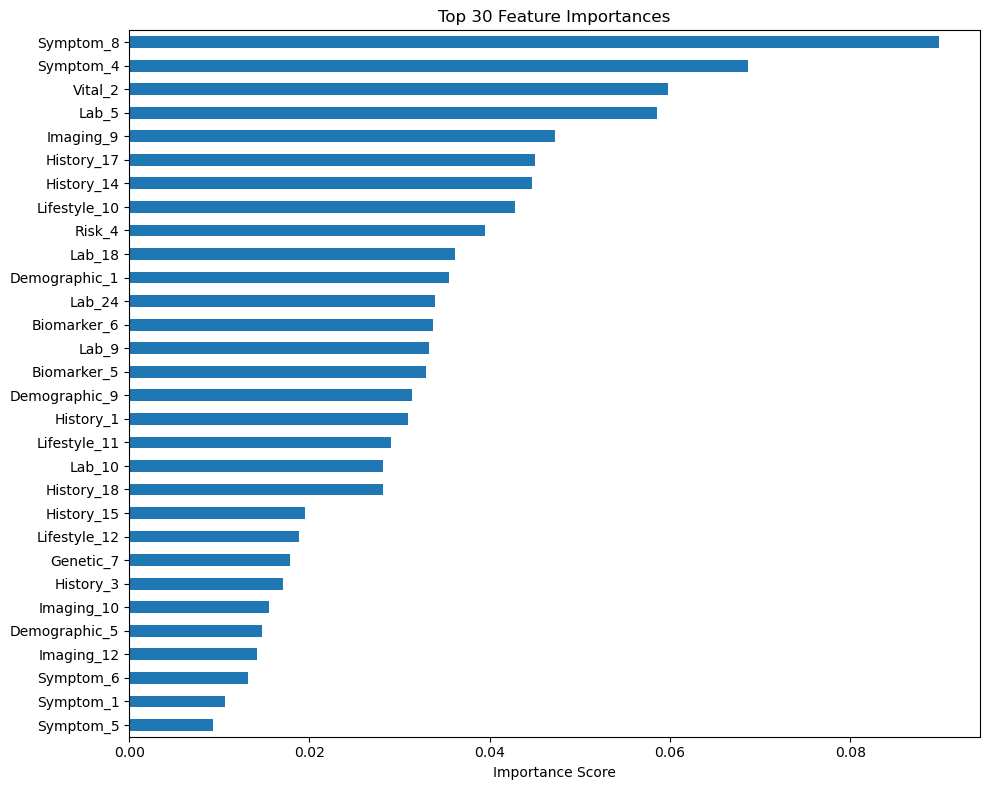

In [56]:
top_features = importances.sort_values(ascending=False).head(30)
print(top_features)

top_features.plot(kind='barh', figsize=(10, 8))
plt.xlabel('Importance Score')
plt.title('Top 30 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [57]:
# ---------------- Final Feature Set (already = selected_features here, but kept for clarity) ----------------
top_feature_names = top_features.index.tolist()
print(top_feature_names)
X_train_final = X_train_balance[top_feature_names]
X_test_final = X_test_scaled[top_feature_names]


['Symptom_8', 'Symptom_4', 'Vital_2', 'Lab_5', 'Imaging_9', 'History_17', 'History_14', 'Lifestyle_10', 'Risk_4', 'Lab_18', 'Demographic_1', 'Lab_24', 'Biomarker_6', 'Lab_9', 'Biomarker_5', 'Demographic_9', 'History_1', 'Lifestyle_11', 'Lab_10', 'History_18', 'History_15', 'Lifestyle_12', 'Genetic_7', 'History_3', 'Imaging_10', 'Demographic_5', 'Imaging_12', 'Symptom_6', 'Symptom_1', 'Symptom_5']


In [58]:
X_train_balance

,Demographic_1,Demographic_5,Demographic_9,Lifestyle_10,Lifestyle_11,Lifestyle_12,History_1,History_3,History_14,History_15,...,Lab_10,Lab_18,Lab_24,Imaging_9,Imaging_10,Imaging_12,Biomarker_5,Biomarker_6,Genetic_7,Risk_4
0,0.620928,0.761635,-0.693448,-0.966477,-0.988923,-0.888284,-0.375949,-0.775547,0.414547,-1.226592,...,-0.968831,-1.418305,-1.394536,-1.336338,-0.447919,0.730951,0.950380,-1.219406,-1.499900,-0.401680
1,-0.177894,1.542906,-0.027740,-0.642889,0.888558,1.708858,0.207037,-1.342684,-0.319626,2.478290,...,0.318772,0.959651,1.476910,0.713575,-1.418270,1.511241,0.812073,1.344363,-0.990445,0.679288
2,0.592080,-1.054701,-1.372896,-0.648385,0.825380,0.779681,0.404812,-1.520086,0.040276,-0.699673,...,-0.417687,0.088077,-0.461454,0.270980,-0.095814,-1.413985,-1.018945,0.872920,-0.880052,-0.279513
3,-0.050825,2.253527,-0.112242,0.235126,-0.103747,-0.657887,-1.453715,-0.089228,0.892135,1.175723,...,-0.986676,-0.523398,1.197742,-1.393204,0.019720,-0.019089,-1.003807,-1.484292,0.996636,1.727313
4,1.946576,1.362507,1.612141,-0.160599,0.145531,1.375679,1.213825,-0.313891,1.451146,-0.941549,...,0.535661,0.915043,0.520449,1.538473,0.727368,1.577239,0.156320,-0.268972,-1.351109,1.499452
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33615,1.037919,2.218597,-0.532016,-1.392232,-1.067043,0.730709,-0.333310,1.753319,1.968802,2.274339,...,-1.453242,0.193514,0.280619,2.305716,0.710314,-1.437328,1.052870,-0.415457,0.234625,1.975618
33616,-0.721585,-1.190730,0.365068,1.052923,0.500474,2.350843,-0.151861,1.235887,1.424287,1.207472,...,1.939906,0.080156,-1.337994,0.524433,-1.562346,-0.355590,-1.317590,1.140468,0.474312,1.688885
33617,0.370954,-1.307722,0.963280,0.803284,-0.509787,0.109446,-0.400357,1.345087,0.965024,-0.543673,...,-0.454148,1.432288,-0.973368,-0.949323,1.925161,-1.211549,0.304421,1.931901,0.075088,1.893656
33618,0.131352,-0.078781,-1.542289,1.813811,1.965037,-0.221495,0.594381,-0.467842,-0.579282,0.846083,...,1.553489,0.864666,-0.111114,0.143264,1.711402,2.158948,1.696615,1.160543,1.005797,-0.645438


In [59]:
# ---------------- Train Final Model ----------------
rf_final = RandomForestClassifier(random_state=42)
rf_final.fit(X_train_final, Y_train_balance)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [67]:
# ---------------- Predict ----------------
Y_pred = rf_final.predict(X_test_final)
Y_pred


array([0., 1., 0., ..., 1., 0., 0.], shape=(10800,))

In [61]:
X_test_final

,Symptom_8,Symptom_4,Vital_2,Lab_5,Imaging_9,History_17,History_14,Lifestyle_10,Risk_4,Lab_18,...,History_15,Lifestyle_12,Genetic_7,History_3,Imaging_10,Demographic_5,Imaging_12,Symptom_6,Symptom_1,Symptom_5
0,0.402987,0.265481,0.882865,0.395543,0.432671,-1.311676,0.203806,0.669324,0.604478,-0.174768,...,-1.539729,0.599640,0.879385,-0.000870,-0.815841,-1.310552,0.300589,-0.380185,-0.864226,-0.200094
1,2.389614,-0.105107,1.760988,1.772241,1.451462,1.755170,1.052928,2.023446,0.305239,1.106515,...,1.989742,-1.402194,2.049829,-1.149529,1.591812,0.900878,2.215220,1.748751,1.711955,-0.725618
2,0.672360,-0.442876,-0.567233,0.635593,-0.901965,0.371073,0.676604,-1.004950,0.808318,-0.792419,...,-0.677746,0.941097,0.824532,-0.260465,-0.921747,1.054526,0.838198,0.016408,-1.480150,-1.123386
3,0.248372,-0.559796,2.074652,0.089154,0.176432,-0.747327,1.639992,0.970240,-1.122326,-1.136931,...,1.607400,1.154249,1.248278,1.234778,0.719803,0.636796,-1.297801,0.704939,-1.068620,1.746621
4,-1.053828,1.353998,0.717491,0.777161,-0.932111,0.130092,-0.327152,0.996347,1.315515,0.276117,...,1.686883,1.671608,0.796419,-0.536500,-1.471911,-0.503901,0.612018,1.364551,0.838138,-1.595045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10795,0.782308,-0.032631,-0.107329,0.320314,-1.591207,-1.485375,1.057717,-1.087393,0.611342,-1.342128,...,-0.187142,-1.465657,0.622258,-0.671435,0.514867,0.661490,0.198155,0.706316,0.858715,-0.691780
10796,-0.309615,-1.279776,-1.244447,0.105568,0.405266,0.266030,-0.902585,0.081233,-1.062615,-0.443789,...,-0.990883,-0.202611,-0.009933,0.579967,-0.989830,0.933803,-0.405452,0.536249,-0.670807,1.152041
10797,0.337705,0.147193,1.127510,-1.204792,1.791287,-0.224858,-1.042166,2.021385,0.048552,-0.505554,...,-0.737359,-0.019811,-0.993188,-0.069364,2.272639,0.452968,-0.393765,-1.209176,2.249688,-1.459693
10798,1.036563,0.600514,-1.595696,-0.782823,-1.302767,-0.834520,0.584918,0.949630,0.713605,0.266510,...,0.654970,-1.025557,-1.381279,0.899838,-1.322679,-0.389351,0.812762,-0.292742,-0.437606,-0.833347


In [62]:
# ---------------- Evaluate ----------------
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred))


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      7190
         1.0       1.00      1.00      1.00      3610

    accuracy                           1.00     10800
   macro avg       1.00      1.00      1.00     10800
weighted avg       1.00      1.00      1.00     10800



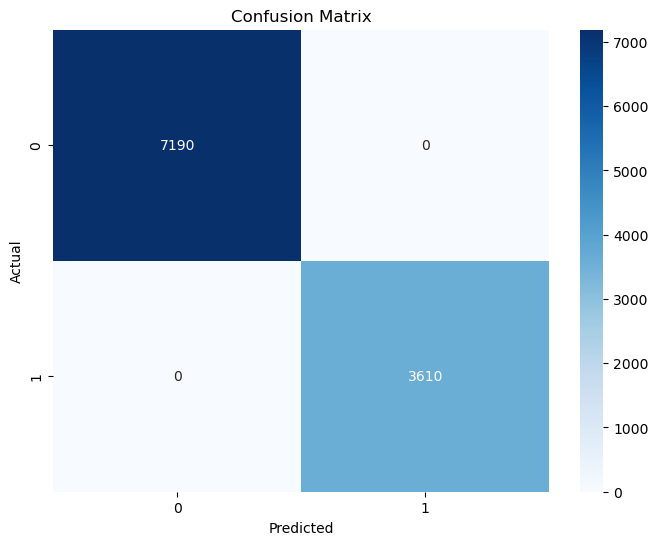

In [63]:
cm = confusion_matrix(Y_test, Y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [77]:
## Healthy Stage Prediction
independent = [[20.15, 20.00, 19.97, 19.97, 19.93, 20.08, 19.97, 20.05, 19.90, 19.97, 19.90, 20.00, 20.03, 20.07, 19.90, 
                19.90, 20.01, 19.90, 19.91, 19.90, 19.96, 19.97, 19.92, 19.85, 20.04, 20.00, 19.90, 20.03, 19.87, 19.89]]
independent= sc.transform(independent)
result = rf_final.predict(independent)
result

array([0.])

In [80]:
## Stage I Prediction
independent = [[39.88, 39.61, 40.21, 40.02, 39.89, 40.12, 40.09, 40.12, 39.89, 39.92, 39.83, 39.93, 39.97, 40.03, 39.99, 40.37, 39.65,
                40.19, 40.02, 40.01, 40.00, 40.08, 39.92, 40.10, 40.08, 40.13, 39.98, 39.52, 40.07, 39.69]]
independent= sc.transform(independent)
result = rf_final.predict(independent)
result

array([1.])